In [5]:
import pandas as pd
import numpy as np
import re

In [2]:
lst_text = ["We are Learning Machine Learning $", 
            "Processing natural - language data.", 
            "10 machine - learning algorithms.", 
            "we Are Mimicing natural intelligence"]

df = pd.DataFrame({'text': lst_text})

In [5]:
df

,text
0,We are Learning Machine Learning $
1,Processing natural - language data.
2,10 machine - learning algorithms.
3,we Are Mimicing natural intelligence


In [7]:
from sklearn.feature_extraction.text import CountVectorizer


In [63]:
c=CountVectorizer(ngram_range=(1,2))
bow=c.fit_transform(df.text)

In [65]:
bow.toarray()


array([[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        1, 1],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
        0, 0],
       [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0],
       [0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
        1, 1]], dtype=int64)

In [67]:
c.get_feature_names_out()

array(['10', '10 machine', 'algorithms', 'are', 'are learning',
       'are mimicing', 'data', 'intelligence', 'language',
       'language data', 'learning', 'learning algorithms',
       'learning machine', 'machine', 'machine learning', 'mimicing',
       'mimicing natural', 'natural', 'natural intelligence',
       'natural language', 'processing', 'processing natural', 'we',
       'we are'], dtype=object)

In [69]:
pd.DataFrame(bow.toarray(),columns=c.get_feature_names_out())

,10,10 machine,algorithms,are,are learning,are mimicing,data,intelligence,language,language data,...,machine learning,mimicing,mimicing natural,natural,natural intelligence,natural language,processing,processing natural,we,we are
0,0,0,0,1,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
1,0,0,0,0,0,0,1,0,1,1,...,0,0,0,1,0,1,1,1,0,0
2,1,1,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,1,0,1,0,0,...,0,1,1,1,1,0,0,0,1,1


## Tf-IDF

In [174]:

from sklearn.feature_extraction.text import TfidfVectorizer

In [75]:
df

,text
0,We are Learning Machine Learning $
1,Processing natural - language data.
2,10 machine - learning algorithms.
3,we Are Mimicing natural intelligence


In [77]:
tfidf=TfidfVectorizer()
tf=tfidf.fit_transform(df.text)

In [79]:
tf

<4x12 sparse matrix of type '<class 'numpy.float64'>'
	with 17 stored elements in Compressed Sparse Row format>

In [81]:
print(tf)

  (0, 11)	0.3779644730092272
  (0, 2)	0.3779644730092272
  (0, 6)	0.7559289460184544
  (0, 7)	0.3779644730092272
  (1, 10)	0.5254727492640658
  (1, 9)	0.41428875116588965
  (1, 5)	0.5254727492640658
  (1, 3)	0.5254727492640658
  (2, 6)	0.43779123108611473
  (2, 7)	0.43779123108611473
  (2, 0)	0.5552826649411127
  (2, 1)	0.5552826649411127
  (3, 11)	0.40104274646999605
  (3, 2)	0.40104274646999605
  (3, 9)	0.40104274646999605
  (3, 8)	0.5086718718935653
  (3, 4)	0.5086718718935653


In [83]:
tf.toarray()

array([[0.        , 0.        , 0.37796447, 0.        , 0.        ,
        0.        , 0.75592895, 0.37796447, 0.        , 0.        ,
        0.        , 0.37796447],
       [0.        , 0.        , 0.        , 0.52547275, 0.        ,
        0.52547275, 0.        , 0.        , 0.        , 0.41428875,
        0.52547275, 0.        ],
       [0.55528266, 0.55528266, 0.        , 0.        , 0.        ,
        0.        , 0.43779123, 0.43779123, 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.40104275, 0.        , 0.50867187,
        0.        , 0.        , 0.        , 0.50867187, 0.40104275,
        0.        , 0.40104275]])

In [95]:
print(tfidf.vocabulary_)

{'we': 11, 'are': 2, 'learning': 6, 'machine': 7, 'processing': 10, 'natural': 9, 'language': 5, 'data': 3, '10': 0, 'algorithms': 1, 'mimicing': 8, 'intelligence': 4}


In [99]:
pd.DataFrame(tf.toarray(),columns=sorted(tfidf.vocabulary_))

,10,algorithms,are,data,intelligence,language,learning,machine,mimicing,natural,processing,we
0,0.000000,0.000000,0.377964,0.000000,0.000000,0.000000,0.755929,0.377964,0.000000,0.000000,0.000000,0.377964
1,0.000000,0.000000,0.000000,0.525473,0.000000,0.525473,0.000000,0.000000,0.000000,0.414289,0.525473,0.000000
2,0.555283,0.555283,0.000000,0.000000,0.000000,0.000000,0.437791,0.437791,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.401043,0.000000,0.508672,0.000000,0.000000,0.000000,0.508672,0.401043,0.000000,0.401043


In [142]:
raw_text = """
We're LaRninG1 Natural-LAnguage-Processing!😀 🚀 ❤️ 
In this\ example wE are goIng to Learn variouS text9 preprocessing steps.
I'm GoIng TO-bE Mr. Rich. ₹ 
"""
text=re.sub("[^a-zA-Z]"," ",raw_text)

<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
C:\Users\pruth\AppData\Local\Temp\ipykernel_40928\266286961.py:1: SyntaxWarning: invalid escape sequence '\ '
  raw_text = """


In [144]:
text=text.lower()

In [146]:
text

' we re larning  natural language processing         in this  example we are going to learn various text  preprocessing steps  i m going to be mr  rich     '

In [148]:
text=text.split()

In [150]:
text

['we',
 're',
 'larning',
 'natural',
 'language',
 'processing',
 'in',
 'this',
 'example',
 'we',
 'are',
 'going',
 'to',
 'learn',
 'various',
 'text',
 'preprocessing',
 'steps',
 'i',
 'm',
 'going',
 'to',
 'be',
 'mr',
 'rich']

In [31]:
from nltk.corpus import stopwords
stop=stopwords.words("english")

In [154]:
text=[x for x in text if x not in stop]

In [156]:
text

['larning',
 'natural',
 'language',
 'processing',
 'example',
 'going',
 'learn',
 'various',
 'text',
 'preprocessing',
 'steps',
 'going',
 'mr',
 'rich']

# stemming and lemmatization

In [35]:
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [37]:
p=PorterStemmer()
l=WordNetLemmatizer()

In [166]:
stemmer_text=[p.stem(x) for x in text]

In [168]:
stemmer_text

['larn',
 'natur',
 'languag',
 'process',
 'exampl',
 'go',
 'learn',
 'variou',
 'text',
 'preprocess',
 'step',
 'go',
 'mr',
 'rich']

In [170]:
lemmatizer_text=[l.lemmatize(x) for x in text] 
lemmatizer_text

['larning',
 'natural',
 'language',
 'processing',
 'example',
 'going',
 'learn',
 'various',
 'text',
 'preprocessing',
 'step',
 'going',
 'mr',
 'rich']

In [208]:
tf=tfidf.fit_transform(stemmer_text)

In [217]:
cv=c.fit_transform(stemmer_text)

In [210]:
print(tf)

  (0, 3)	1.0
  (1, 6)	1.0
  (2, 2)	1.0
  (3, 8)	1.0
  (4, 0)	1.0
  (5, 1)	1.0
  (6, 4)	1.0
  (7, 12)	1.0
  (8, 11)	1.0
  (9, 7)	1.0
  (10, 10)	1.0
  (11, 1)	1.0
  (12, 5)	1.0
  (13, 9)	1.0


In [219]:
pd.DataFrame(cv.toarray(),columns=c.get_feature_names_out())

,exampl,go,languag,larn,learn,mr,natur,preprocess,process,rich,step,text,variou
0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,1,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,1
8,0,0,0,0,0,0,0,0,0,0,0,1,0
9,0,0,0,0,0,0,0,1,0,0,0,0,0


In [223]:
df=pd.read_csv("./email_data.xls")

In [225]:
df

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\nthe transport v...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0
5168,2933,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


In [235]:
df.drop(columns="Unnamed: 0",axis=1,inplace=True)

In [237]:
df

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\nthis deal is to ...,0
...,...,...,...
5166,ham,Subject: put the 10 on the ft\nthe transport v...,0
5167,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0
5168,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0
5169,ham,Subject: industrial worksheets for august 2000...,0


label
ham     3672
spam    1499
Name: count, dtype: int64


(array([3672., 1499.]),
 array([0. , 0.5, 1. ]),
 <BarContainer object of 2 artists>)

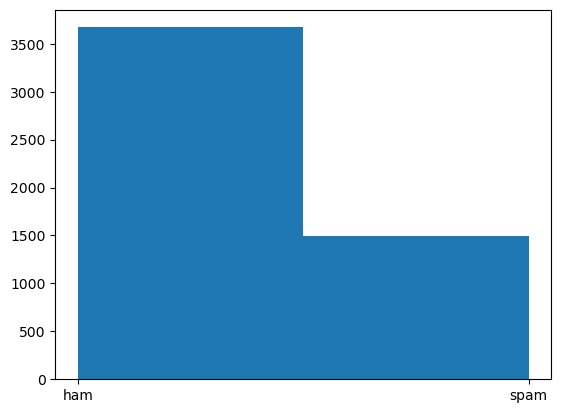

In [260]:
a=df.label.value_counts()
print(a)
import matplotlib.pyplot as plt
plt.hist(df.label,bins=2)

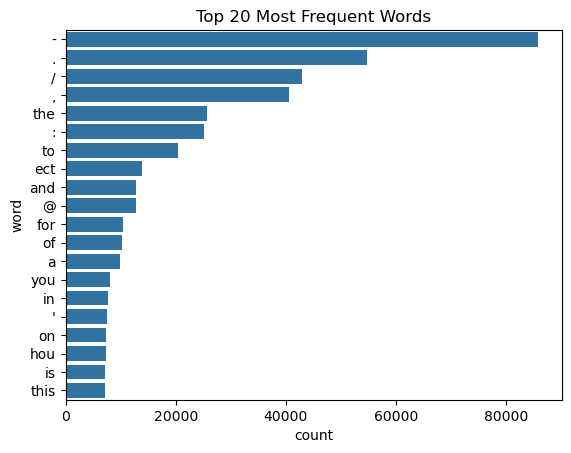

In [271]:
from collections import Counter
import seaborn as sns
# Get all words in the text
all_words = " ".join(df['text'].values).split()
word_counts = Counter(all_words)

# Get the most common words
common_words = word_counts.most_common(20)

# Convert to DataFrame for plotting
common_words_df = pd.DataFrame(common_words, columns=['word', 'count'])

# Plot the most common words
sns.barplot(data=common_words_df, x='count', y='word')
plt.title('Top 20 Most Frequent Words')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from textblob import TextBlob


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\pruth\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\pruth\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\pruth\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [287]:
! pip install textblob

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   --------------------------------- ------ 524.3/624.3 kB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 624.3/624.3 kB 1.8 MB/s eta 0:00:00


In [275]:
xt,xtt,yt,ytt=train_test_split(df.text,df.label,test_size=0.9,random_state=1)

In [41]:
def clean(text):
    text=re.sub("[^a-zA-Z]"," ",text)

    text=text.lower()
    text=text.split()
  
    text=[l.lemmatize(x) for x in text ]
    
    return " ".join(text)

In [325]:
c=CountVectorizer(preprocessor=clean)



In [45]:
# c.fit_transform(xt)
clean("The United States of America (U.S.A. or USA), commonly known as the United States (U.S. or US) or America, is a country primarily located in North America.")

'the united state of america u s a or usa commonly known a the united state u s or u or america is a country primarily located in north america'

In [9]:
'the United States of America (U.S.A. or USA), commonly know as the United States (U.S. or US) or America, be a country primarily locate in North America.'

'the United States of America (U.S.A. or USA), commonly know as the United States (U.S. or US) or America, be a country primarily locate in North America.'

In [342]:
# import feature extraction methods from sklearn
from sklearn.feature_extraction.text import CountVectorizer

# instantiate a vectoriezer
bow_vect = CountVectorizer(
                           
                           ngram_range=(1, 1), 
                           lowercase=False, 
                           preprocessor=clean, 
                           stop_words=None)

# use it to extract features from training data
%time X_train_transformed = bow_vect.fit_transform(xt)

print()
print(f"Shape of X_train_transformed (# of docs, # of unique vocabulary): {X_train_transformed.shape}")
print(f"Type of X_train_transformed (i.e. Compressed Sparse Row (CSR) format): {type(X_train_transformed)}")
print(f"Vocabulary learned: {bow_vect.get_feature_names_out()[:10]}")

KeyboardInterrupt: 

NameError: name 'X_train_transformed' is not defined